### Product Dataset – Exploratory Data Analysis (EDA)

This notebook performs an exploratory data analysis on a product dataset containing information such as price, stock levels, categories, brands, colors, availability, etc.

The goal of this analysis is to clean the dataset, understand its structure, explore key patterns, and visualize important relationships across different product attributes.

In [ ]:
# importing all the libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Appling ggplot style to all the plots
plt.style.use("ggplot")

# Load the dataset from csv file
df = pd.read_csv("products-1000.csv")

# Printing the number of rows and columns int the dataset
print("Shape:", df.shape)

# Display the first 5 rows of the dataset
df.head()

Shape: (1000, 13)


,Index,Name,Description,Brand,Category,Price,Currency,Stock,EAN,Color,Size,Availability,Internal ID
0,1,Thermostat Drone Heater,Consumer approach woman us those star.,Bradford-Yu,Kitchen Appliances,74,USD,139,8.619790e+12,Orchid,Medium,backorder,38
1,2,Ultra Speaker Iron Grill Advanced One,Point suggest easy money operation could white.,Douglas Group,Fitness Equipment,510,USD,351,3.057220e+12,MediumSeaGreen,Small,backorder,27
2,3,Watch Headphones Kettle,Reach husband education.,Landry-Austin,Beauty & Personal Care,254,USD,409,9.825250e+12,Lavender,XXL,pre_order,2
3,4,Portable Toaster Clock Monitor Silent,Always choose school poor table main.,"Odom, Norton and Foster",Makeup,69,USD,119,9.490810e+12,Pink,XL,in_stock,94
4,5,Pro Toaster Oven,Worry put discuss easy back too career.,"Fowler, Mendoza and Mcdaniel",Automotive,525,USD,727,4.726650e+12,LightCoral,XL,in_stock,95


In [ ]:
# Summary information about the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Index         1000 non-null   int64  
 1   Name          1000 non-null   object 
 2   Description   1000 non-null   object 
 3   Brand         1000 non-null   object 
 4   Category      1000 non-null   object 
 5   Price         1000 non-null   int64  
 6   Currency      1000 non-null   object 
 7   Stock         1000 non-null   int64  
 8   EAN           1000 non-null   float64
 9   Color         1000 non-null   object 
 10  Size          1000 non-null   object 
 11  Availability  1000 non-null   object 
 12  Internal ID   1000 non-null   int64  
dtypes: float64(1), int64(4), object(8)
memory usage: 101.7+ KB


In [ ]:
# Cleaning the dataset by converting the price and stock columns to numeric and removing all the null values by replacing it with the median of that column
df.columns = df.columns.str.strip().str.lower().str.replace(" ","_")

df['price'] = pd.to_numeric(df['price'], errors='coerce')
df['stock'] = pd.to_numeric(df['stock'], errors='coerce')

df['price'] = df['price'].fillna(df['price'].median())
df['price'] = df['price'].fillna(0)

# Converting the ean column to string to avoid large numbers rounding and showing scientific values
df["ean"] = df["ean"].astype(str)


df.head()

,index,name,description,brand,category,price,currency,stock,ean,color,size,availability,internal_id
0,1,Thermostat Drone Heater,Consumer approach woman us those star.,Bradford-Yu,Kitchen Appliances,74,USD,139,8619790000000.0,Orchid,Medium,backorder,38
1,2,Ultra Speaker Iron Grill Advanced One,Point suggest easy money operation could white.,Douglas Group,Fitness Equipment,510,USD,351,3057220000000.0,MediumSeaGreen,Small,backorder,27
2,3,Watch Headphones Kettle,Reach husband education.,Landry-Austin,Beauty & Personal Care,254,USD,409,9825250000000.0,Lavender,XXL,pre_order,2
3,4,Portable Toaster Clock Monitor Silent,Always choose school poor table main.,"Odom, Norton and Foster",Makeup,69,USD,119,9490810000000.0,Pink,XL,in_stock,94
4,5,Pro Toaster Oven,Worry put discuss easy back too career.,"Fowler, Mendoza and Mcdaniel",Automotive,525,USD,727,4726650000000.0,LightCoral,XL,in_stock,95


In [ ]:
# Creating a new column is_available using the information from availability column

df['is_available'] = df['availability'].str.lower() == 'in_stock'
df["is_available"] = df["availability"].astype(str).str.contains("stock", case=False)
df['is_available'] = df['availability'].str.lower().isin(['in_stock', 'limited_stock'])
df

,index,name,description,brand,category,price,currency,stock,ean,color,size,availability,internal_id,is_available
0,1,Thermostat Drone Heater,Consumer approach woman us those star.,Bradford-Yu,Kitchen Appliances,74,USD,139,8619790000000.0,Orchid,Medium,backorder,38,False
1,2,Ultra Speaker Iron Grill Advanced One,Point suggest easy money operation could white.,Douglas Group,Fitness Equipment,510,USD,351,3057220000000.0,MediumSeaGreen,Small,backorder,27,False
2,3,Watch Headphones Kettle,Reach husband education.,Landry-Austin,Beauty & Personal Care,254,USD,409,9825250000000.0,Lavender,XXL,pre_order,2,False
3,4,Portable Toaster Clock Monitor Silent,Always choose school poor table main.,"Odom, Norton and Foster",Makeup,69,USD,119,9490810000000.0,Pink,XL,in_stock,94,True
4,5,Pro Toaster Oven,Worry put discuss easy back too career.,"Fowler, Mendoza and Mcdaniel",Automotive,525,USD,727,4726650000000.0,LightCoral,XL,in_stock,95,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,996,Silent Router Phone Portable Automatic,Piece the fight near never once bank.,Huffman Group,Toys & Games,903,USD,737,8227580000000.0,MediumAquaMarine,XL,limited_stock,33,True
996,997,Digital Treadmill Clean Go,Apply drive outside reach apply.,Woodward Group,Toys & Games,8,USD,330,522634000000.0,PaleVioletRed,Medium,out_of_stock,9,False
997,998,Wireless Vacuum Shaver,Line cup course student each about.,Ramos-Cardenas,Beauty & Personal Care,615,USD,630,1892830000000.0,PaleVioletRed,Extra Large,pre_order,4,False
998,999,Portable Cooker Brush 360 Digital Mini,History feel worry painting only power bad.,Hooper-Bender,Men's Clothing,811,USD,566,1683590000000.0,LightGreen,S,in_stock,65,True


In [ ]:
# Show summary statistics for all columns
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
index,1000.0,NaN,NaN,NaN,500.5,288.819436,1.0,250.75,500.5,750.25,1000.0
name,1000,919,Projector,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN
description,1000,1000,Consumer approach woman us those star.,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
brand,1000,996,Christensen and Sons,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
category,1000,34,Books & Stationery,39,NaN,NaN,NaN,NaN,NaN,NaN,NaN
price,1000.0,NaN,NaN,NaN,506.549,283.773556,1.0,284.75,497.5,757.25,999.0
currency,1000,1,USD,1000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
stock,1000.0,NaN,NaN,NaN,501.782,292.151318,2.0,243.0,504.0,750.25,999.0
ean,1000,1000,8619790000000.0,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
color,1000,140,PaleVioletRed,17,NaN,NaN,NaN,NaN,NaN,NaN,NaN


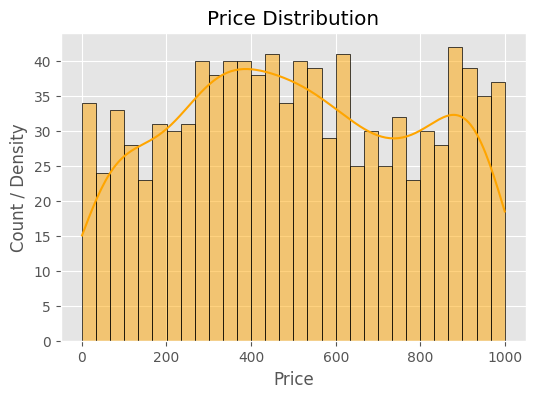

In [ ]:
# Plots a histogram with a kde line of Price column showing price distribution and density in one graph

plt.figure(figsize=(6,4))
sns.histplot(df['price'],bins=30,kde=True,color='orange',edgecolor='black')
plt.title("Price Distribution")
plt.xlabel("Price")
plt.ylabel("Count / Density")
plt.show()


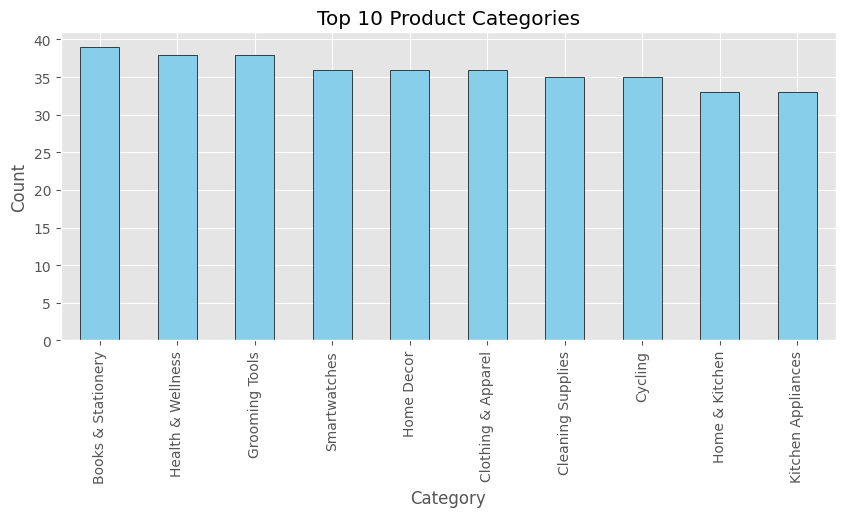

In [ ]:
# Plots a bargraph of top 10 product categories using the category column

plt.figure(figsize=(10,4))
df["category"].value_counts().head(10).plot(kind="bar",color='skyblue',edgecolor='black')
plt.title("Top 10 Product Categories")
plt.xlabel("Category")
plt.ylabel("Count")
plt.show()

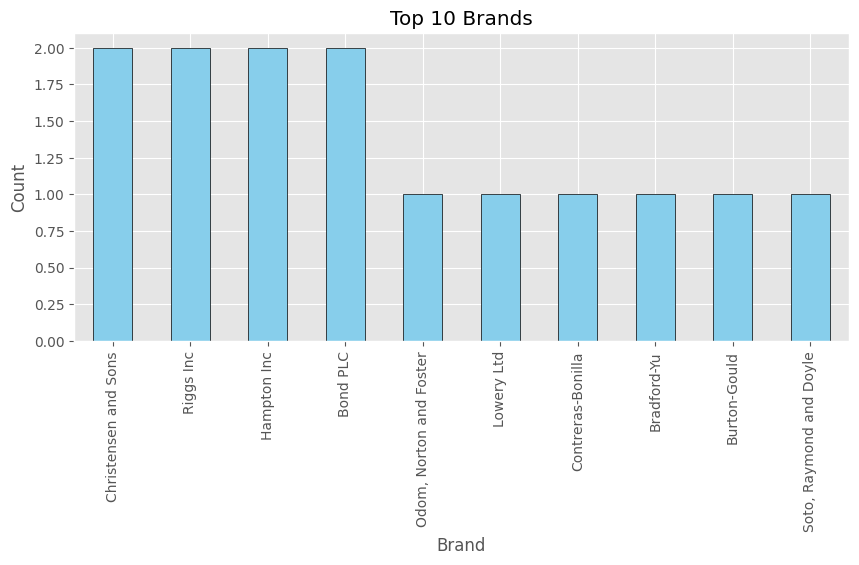

In [ ]:
# Plots a bargraph of top 10 product brands using the brand column

plt.figure(figsize=(10,4))
df['brand'].value_counts().head(10).plot(kind='bar',color='skyblue',edgecolor='black')
plt.title("Top 10 Brands")
plt.xlabel("Brand")
plt.ylabel('Count')
plt.show()

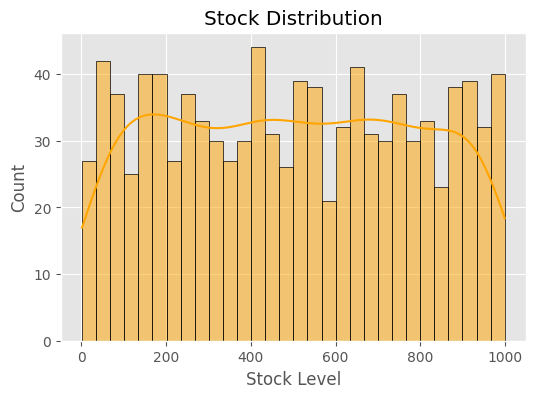

In [ ]:
# Plots histogram and kde of stock using stock column showing stock level and density

plt.figure(figsize=(6,4))
sns.histplot(df['stock'],bins=30,kde=True,color='orange',edgecolor='black')
plt.xlabel('Stock Level')
plt.ylabel('Count')
plt.title('Stock Distribution')
plt.show()

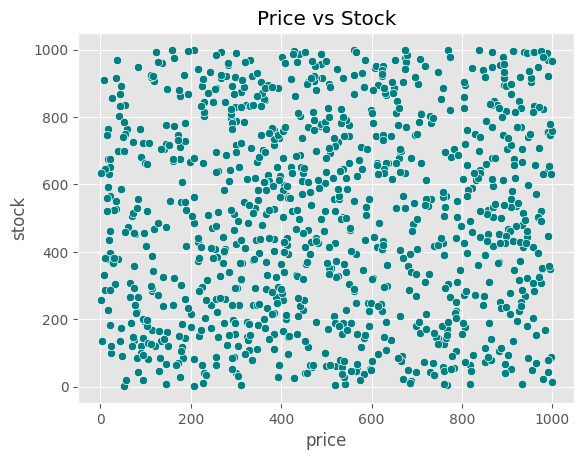

In [ ]:
# Scatter plot to visualize the relationship between price and stock levels

df_price_to_stock = df[['price','stock']].copy()
sns.scatterplot(data=df_price_to_stock,x='price',y='stock',color='teal')
plt.title("Price vs Stock")
plt.show()

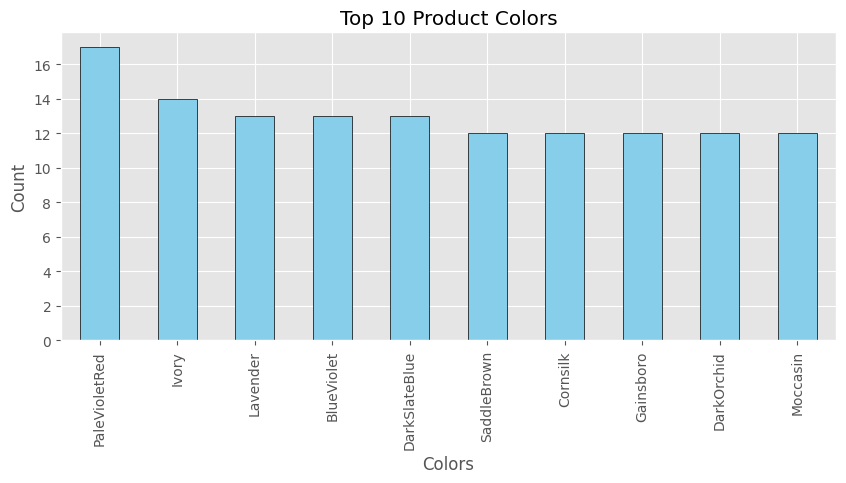

In [ ]:
# Plots bargraph showing top 10 product colors using the colors column

plt.figure(figsize=(10,4))
df["color"].value_counts().head(10).plot(kind="bar",color='skyblue',edgecolor='black')
plt.title("Top 10 Product Colors")
plt.xlabel("Colors")
plt.ylabel("Count")
plt.show()


### Conclusion

This analysis provided a comprehensive overview of the products 000 dataset by cleaning the data, exploring its structure, and visualizing key product attributes. After standardizing column formats and handling missing values, the dataset became suitable for effective analysis. The distribution plots revealed that both price and stock show a high degree of dispersion, with values ranging from very low to extremely high. This suggests strong variability across products, and the presence of outliers. Category, brand, and color visualizations highlighted significant concentration only a handful of categories and brands dominate the product assortment.

The analysis of price and stock levels showed that both variables are widely dispersed, suggesting that products vary greatly in both cost and inventory availability. Despite this wide spread, the scatterplot revealed no meaningful correlation between the two, indicating that higher priced products are not necessarily stocked more or less than lower priced ones.

Creating the availability feature also helped categorize items clearly as in stock or limited, adding useful structure to the dataset. Overall, the analysis provides a solid understanding of how prices, stock quantities, categories, and product attributes are distributed. These insights establish a strong base for more advanced work such as trend analysis, inventory optimization, or building product recommendation systems.